In [1]:
# 1. Load the Taxis Dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
# 2. Handling Missing Values
# Step 1: Check missing values
df.isnull().sum()
missing_values = df.isnull().sum()

missing_values[missing_values > 0]
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]


# Step 2: Check column data types
df.dtypes
# Step 3: Impute numerical columns
numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())
# Step 4: Impute categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_2268\1307213754.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [5]:
# 3. Convert Pickup to Datetime
df['pickup'] = pd.to_datetime(df['pickup'])
print(df['pickup'].dtype)

datetime64[us]


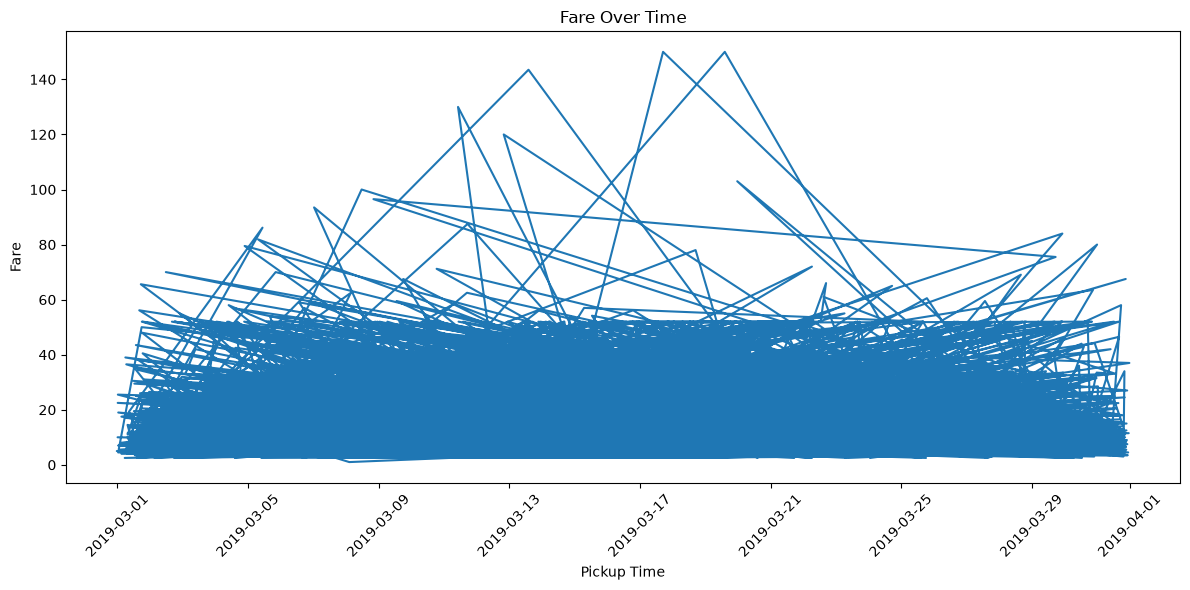

In [8]:
# 4. Line Chart – Fare Over Time
plt.figure(figsize=(12, 6))

plt.plot(df['pickup'], df['fare'])

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

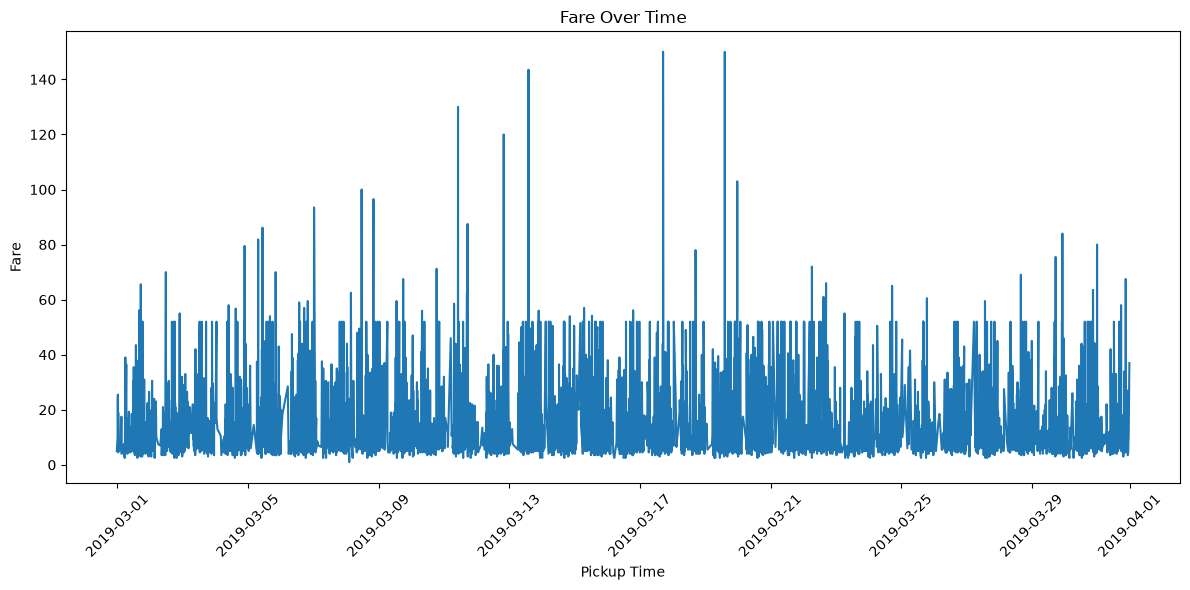

In [ ]:
# 4. Line Chart – Fare Over Time
df_sorted = df.sort_values('pickup')

plt.figure(figsize=(12, 6))

plt.plot(df_sorted['pickup'], df_sorted['fare'])

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pickup_borough
Bronx         2078.91
Brooklyn      6327.48
Manhattan    59426.42
Queens       16382.06
Name: fare, dtype: float64


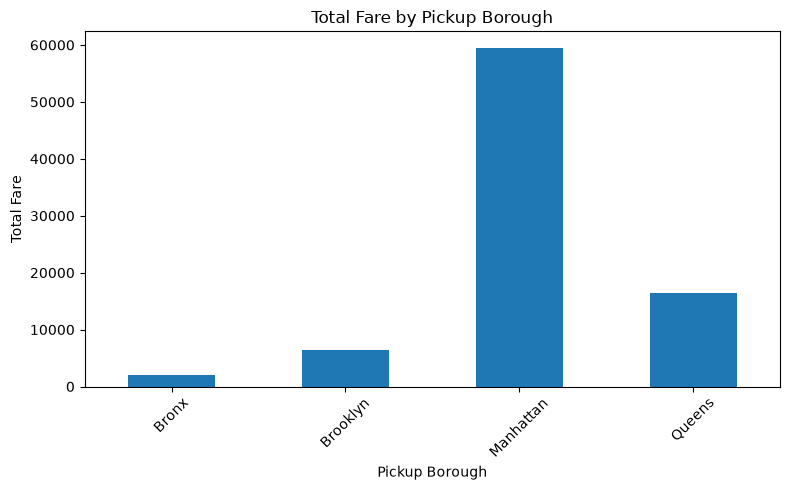

In [10]:
# 5. Bar Chart – Total Fare by Pickup Borough

borough_fare = df.groupby('pickup_borough')['fare'].sum()

print(borough_fare)

plt.figure(figsize=(8, 5))

borough_fare.plot(kind='bar')

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

payment
credit card    4621
cash           1812
Name: count, dtype: int64


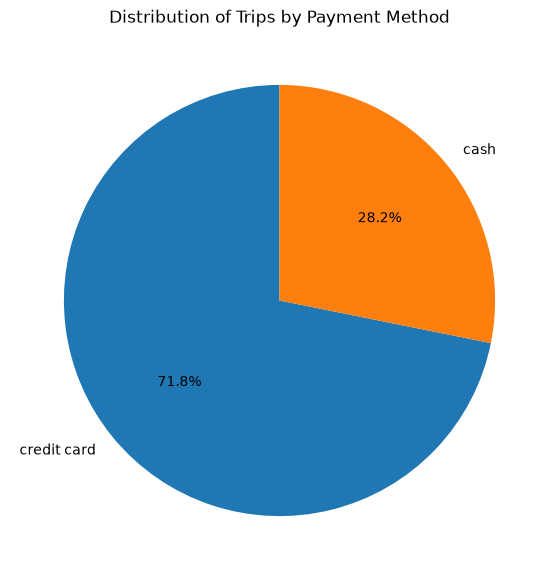

In [11]:
# 6. Pie Chart – Payment Method Distribution

payment_counts = df['payment'].value_counts()

print(payment_counts)
plt.figure(figsize=(7, 7))

payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')
plt.title('Distribution of Trips by Payment Method')

plt.show()

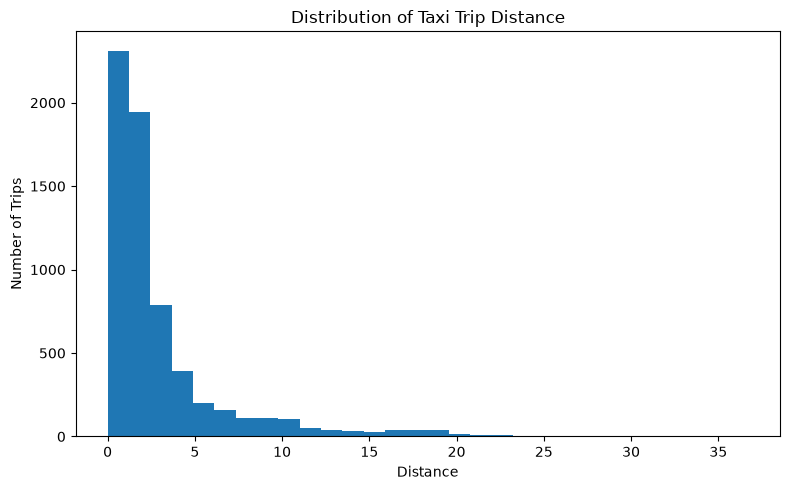

In [12]:
# 7. Histogram – Distance Distribution

plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=30)

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Taxi Trip Distance')

plt.tight_layout()
plt.show()

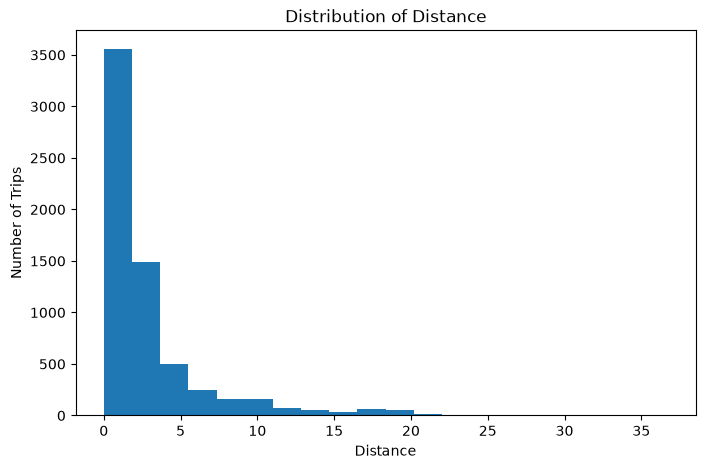

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(df['distance'], bins=20)

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Distance')

plt.show()

<Figure size 1000x600 with 0 Axes>

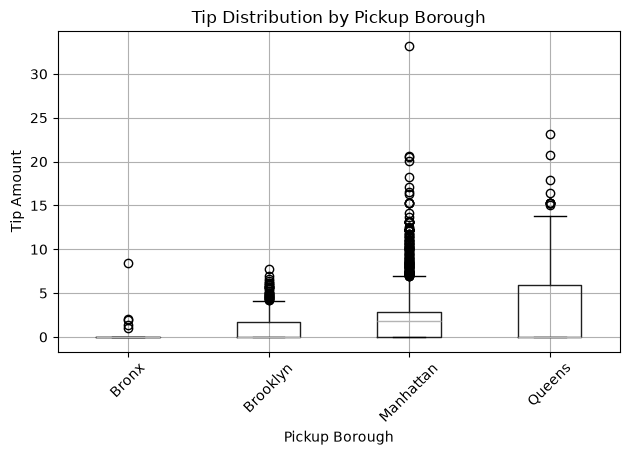

In [15]:
# 8. Box Plot – Tip Amount by Pickup Borough


plt.figure(figsize=(10, 6))

df.boxplot(
    column='tip',
    by='pickup_borough'
)

plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Tip Distribution by Pickup Borough')

plt.suptitle('')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

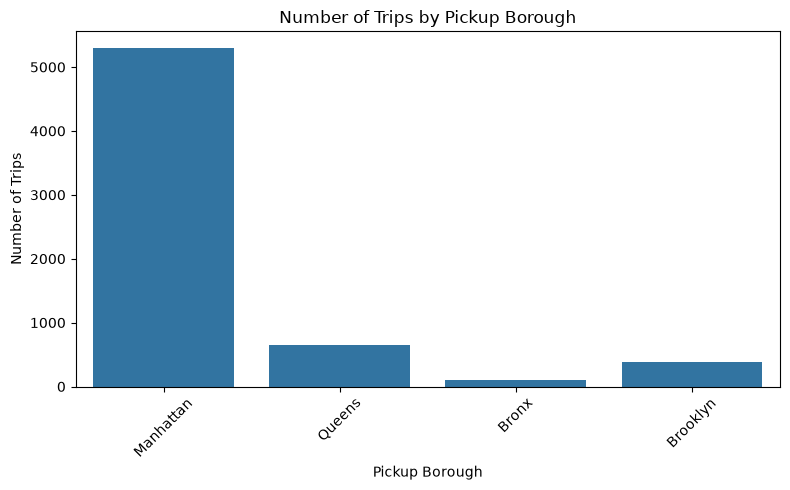

In [16]:
# 9. Count Plot – Trips by Pickup Borough

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='pickup_borough'
)

plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

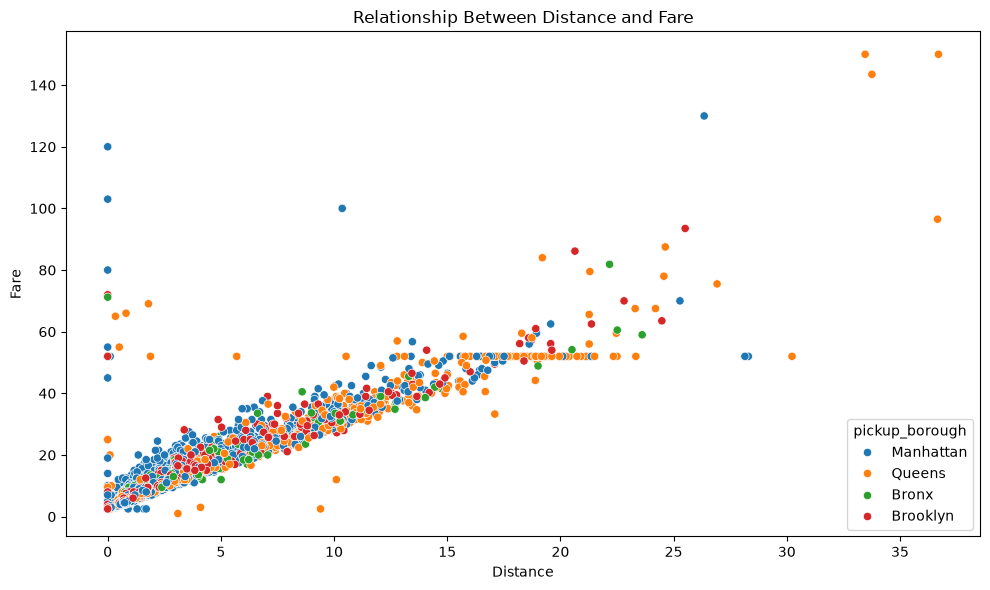

In [17]:
# 10. Scatter Plot – Distance vs Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough'
)

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')

plt.tight_layout()
plt.show()

          distance      fare       tip     tolls     total
distance  1.000000  0.920108  0.452589  0.635267  0.904676
fare      0.920108  1.000000  0.488612  0.609307  0.974358
tip       0.452589  0.488612  1.000000  0.413619  0.646186
tolls     0.635267  0.609307  0.413619  1.000000  0.683142
total     0.904676  0.974358  0.646186  0.683142  1.000000


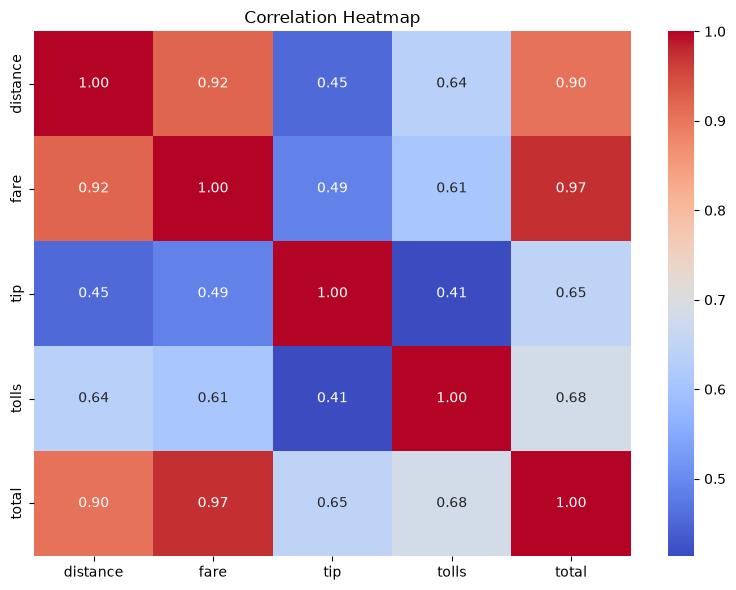

In [19]:
# 11. Heatmap – Correlation Matrix
corr_columns = ['distance', 'fare', 'tip', 'tolls', 'total']

correlation = df[corr_columns].corr()

print(correlation)
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()


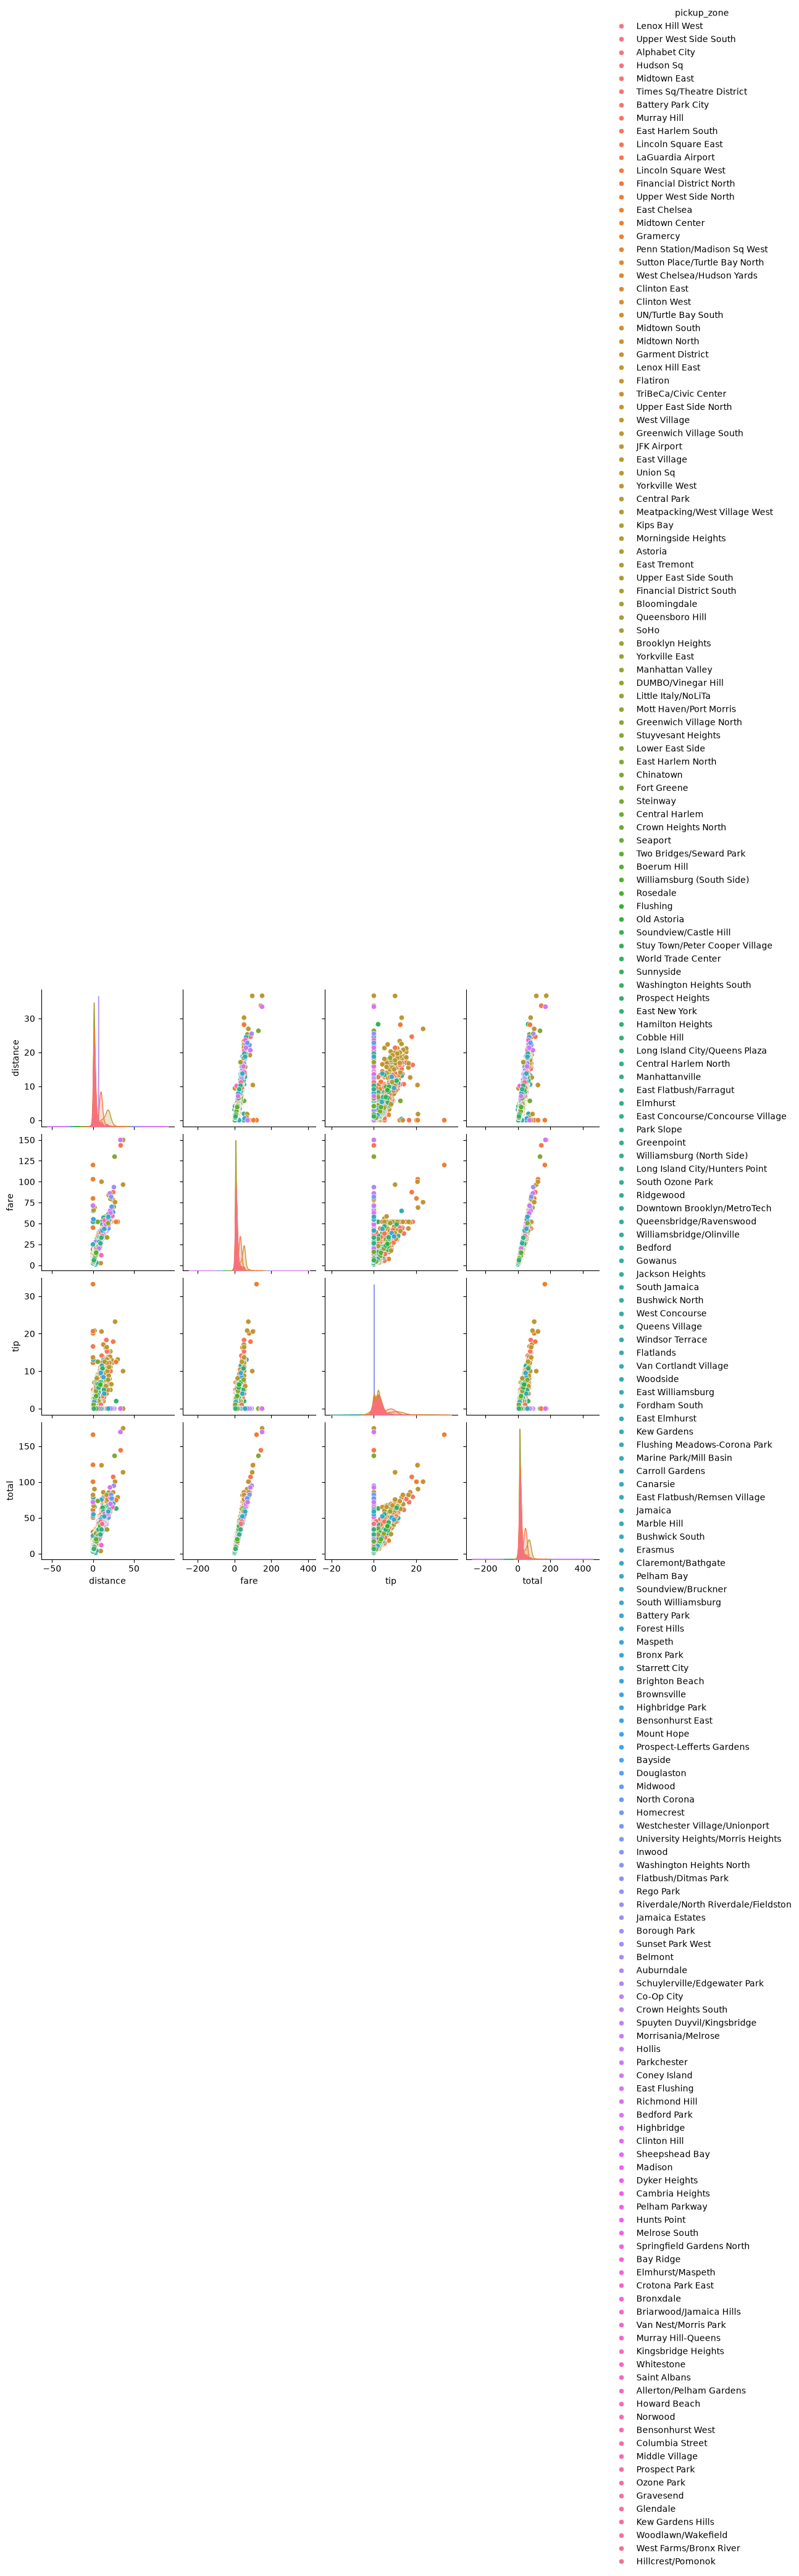

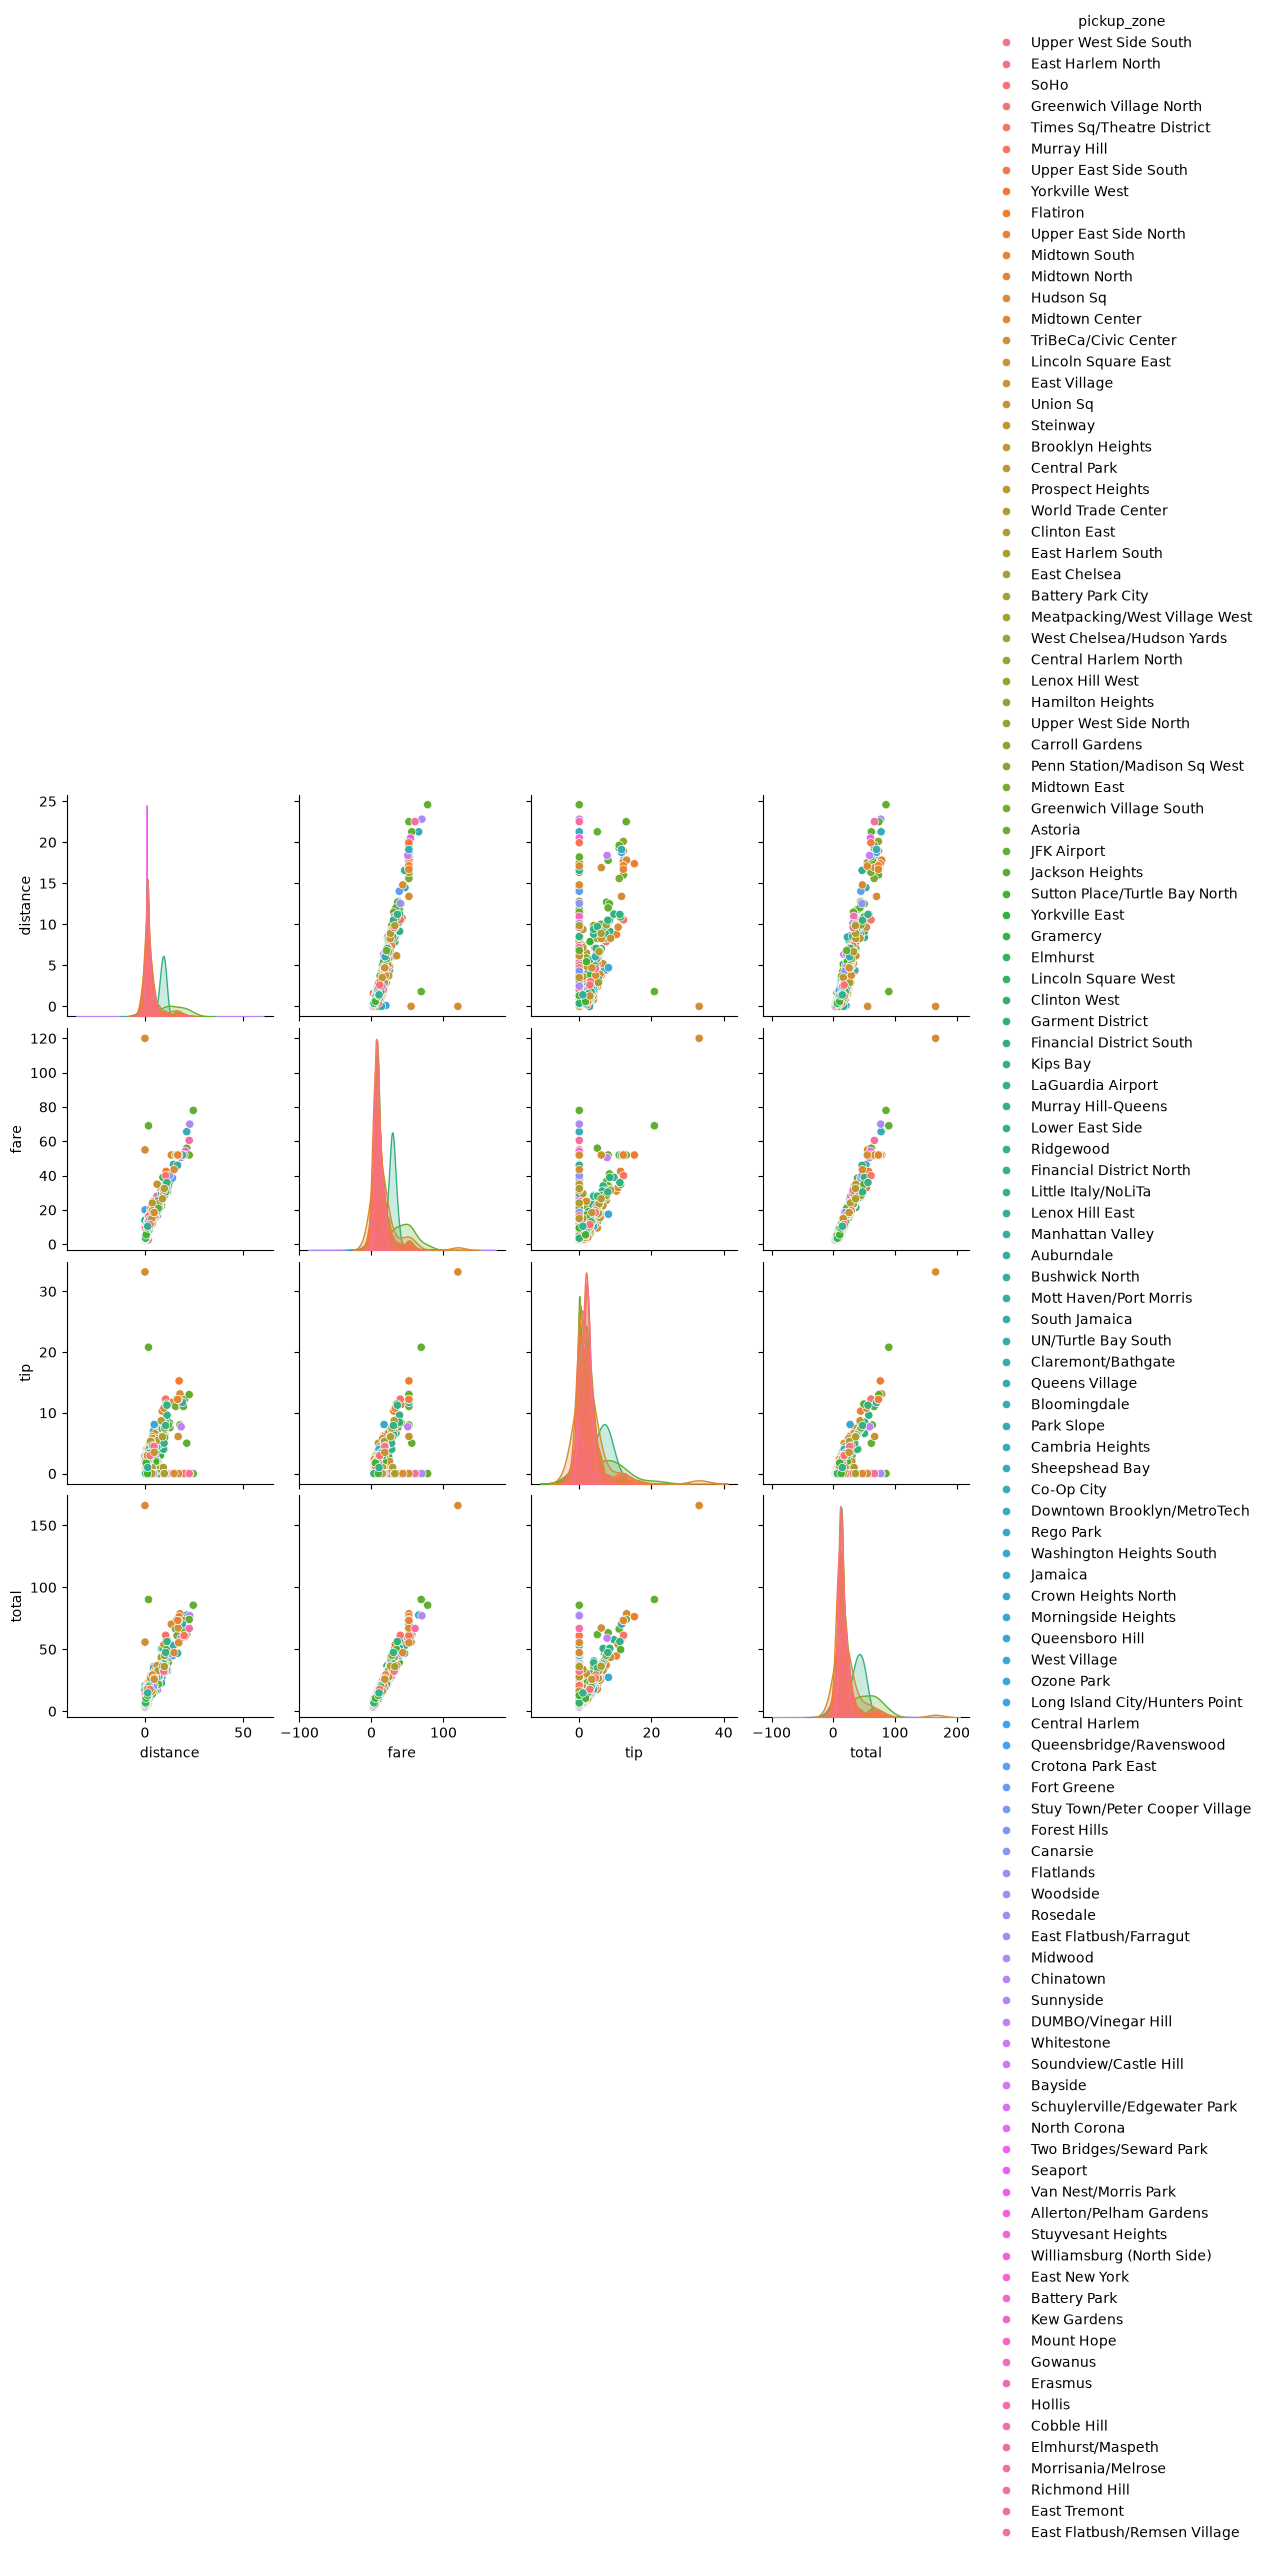

In [18]:
# 12. Pair Plot
pair_columns = ['distance', 'fare', 'tip', 'total', 'pickup_zone']

sns.pairplot(
    df[pair_columns],
    hue='pickup_zone'
)

plt.show()
sample_df = df[pair_columns].sample(
    n=min(1000, len(df)),
    random_state=42
)

sns.pairplot(
    sample_df,
    hue='pickup_zone'
)

plt.show()


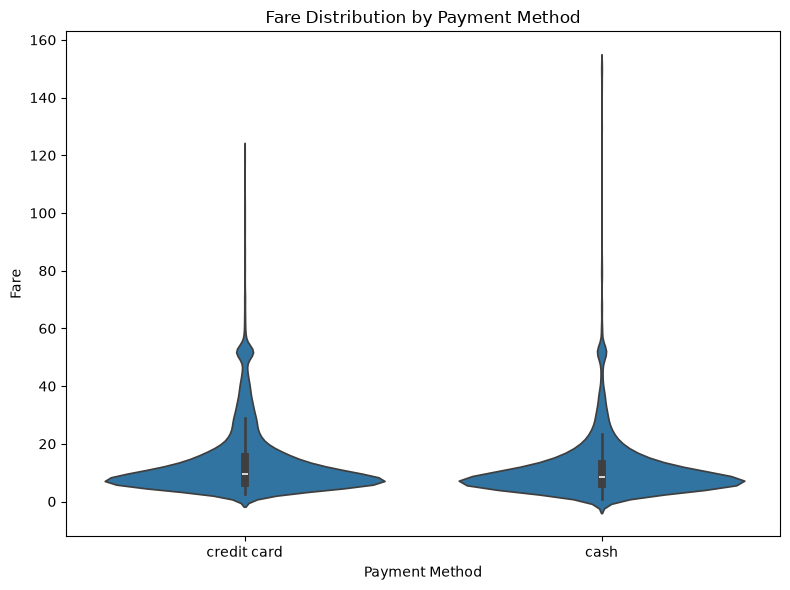

In [20]:
# 13. Violin Plot – Fare by Payment Method

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')

plt.tight_layout()
plt.show()